# Objective sweep results

Loads a finished (or in-progress) run of `experiments/run_objective_sweep.py`
(or any `experiments.sweep.run_sweep` call) and inspects it: the headline
sim-vs-bounds table, a plot against a swept axis, and how to drop into one
trial's full detail.

Nothing here re-runs the sweep -- it only reads what is already on disk under
`experiments/results/<run_name>/`. See `experiments/README.md` for what each
column means and for the sweep-side gotchas (pinning `arrival_horizon`,
the window's two edges, DW's LB-only default, etc.).

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from experiments.objective_sweep import load_results, comparison_table
from experiments.core import DEFAULT_OUT_DIR
from visualization.style import new_figure, style_axes, style_legend, palette

## Point this at a run

`RUN_NAME` is the sub-directory name you passed as `run_name` to `run_sweep`
(or the auto-generated `sweep_<timestamp>` if you didn't pass one -- check
`experiments/results/` on disk, or the last line `run_sweep` printed, if
you're not sure).

In [2]:
RUN_NAME = "test"  # <-- edit to the run you want to inspect

run_dir = DEFAULT_OUT_DIR / RUN_NAME
df = load_results(RUN_NAME)
print(f"{len(df)} trial(s) loaded from {run_dir / 'results.csv'}")
df.head()

2 trial(s) loaded from D:\OneDrive - University of Toronto\Uni\Ph.D\Thesis\Chapter 2 - Queueing\Python Codes\experiments\results\test\results.csv


,trial_id,n_piles,n_connectors,n_modules,p_module,queue_capacity,mean_interarrival,max_time,warmup_period,flush_queue_at_warmup,...,dw_mean_sojourn_LB,dw_UB,dw_gap,dw_total_sojourn_UB,dw_mean_sojourn_UB,dw_whole_module_feasible,dw_n_vehicles,dw_n_optimized,dw_K,dw_runtime_s
0,0,1,2,6,25.0,1000,30.0,120,360,False,...,28.715783,NaN,NaN,NaN,NaN,NaN,4,4,60,0.323358
1,1,1,2,6,25.0,1000,60.0,120,360,False,...,24.703462,NaN,NaN,NaN,NaN,NaN,3,3,60,2.202144


## Run metadata

`run_meta.json` records the sweep definition and timing: every `TrialConfig`
that was queued (as a dict, via `to_row()`), which of the three stages
(`sim`/`exact`/`dw`) were switched on, and start/finish/total runtime.

In [3]:
meta = json.loads((run_dir / "run_meta.json").read_text())
print("stages run:", meta["stages"])
print("n_trials:  ", meta["n_trials"])
print("started:   ", meta["started"], " finished:", meta.get("finished", "(in progress)"))
if "total_runtime_s" in meta:
    print(f"total runtime: {meta['total_runtime_s']:.1f} s")

stages run: {'sim': True, 'exact': True, 'dw': True}
n_trials:   2
started:    2026-09-09T14:33:52  finished: 2026-09-09T14:33:56
total runtime: 4.0 s


## Headline view: sim vs. grid vs. exact vs. DW's lower bound

`comparison_table` pulls out the four sources' mean sojourn for one cohort
(default `"all"`) alongside the knobs that identify each row.

**`group` is the important argument.** Every source now reports two
populations:

* `"arrived"` (the default) -- every vehicle the models were given, with
  unfinished ones censored at the horizon. All four columns cover the same
  set, so this is the one to compare on.
* `"completed"` -- only vehicles that received their full energy. Readable,
  but it conditions on an outcome: it drops precisely the longest sojourns,
  and the simulation and the models drop *different* vehicles.

Comparing a `completed` number against an `arrived` one is what makes a
proven optimum look *worse* than feasible FIFO. The `sim_n`/`grid_n`/
`exact_n` columns are shown so any residual mismatch stays visible.

Remember `sim` is continuous-time and NOT the like-for-like target -- compare
against `grid` (that same schedule replayed on the `delta` slot grid);
`dw_LB` is a certified lower bound and `exact` is the MILP's incumbent, so on
every row you should see `grid >= exact >= dw_LB`.

In [11]:
GROUP = "arrived"   # "arrived" (comparable) | "completed" (finished only)

table = comparison_table(df, cohort="all", group=GROUP)
table

,mean_interarrival,max_time,delta,mip_gap,gap_tolerance,sim,grid,exact,dw_LB,sim_n,grid_n,exact_n,exact_status,dw_status,sim_runtime_s,exact_runtime_s,dw_runtime_s
0,30.0,120,2.0,0.0001,0.000001,30.786001,31.5,29.5,28.715783,4.0,4.0,4.0,OPTIMAL,CONVERGED,0.009486,0.848778,0.323358
1,60.0,120,2.0,0.0001,0.000001,25.555616,26.0,26.0,24.703462,3.0,3.0,3.0,OPTIMAL,CONVERGED,0.005687,0.496066,2.202144


## All columns

`results.csv` is wide (config knobs + populations + per-source, per-cohort
metrics -- see the README's column-group table). Group by prefix to see
what's available for a given source.

In [8]:
prefixes = ["inst_", "sim_", "grid_", "exact_", "dw_"]
for p in prefixes:
    cols = [c for c in df.columns if c.startswith(p)]
    print(f"{p:8s} ({len(cols)} columns): {cols}")

inst_    (8 columns): ['inst_n_vehicles', 'inst_n_dropped_late_arrivals', 'inst_n_optimized', 'inst_n_boundary_vehicles', 'inst_n_discarded', 'inst_n_measurement', 'inst_n_queued', 'inst_n_boundary']
sim_     (23 columns): ['sim_clock_end', 'sim_runtime_s', 'sim_completed_measurement_n', 'sim_completed_measurement_total_sojourn', 'sim_completed_measurement_mean_sojourn', 'sim_completed_measurement_queued_n', 'sim_completed_measurement_queued_total_sojourn', 'sim_completed_measurement_queued_mean_sojourn', 'sim_completed_all_n', 'sim_completed_all_total_sojourn', 'sim_completed_all_mean_sojourn', 'sim_arrived_measurement_n', 'sim_arrived_measurement_n_censored', 'sim_arrived_measurement_total_sojourn', 'sim_arrived_measurement_mean_sojourn', 'sim_arrived_measurement_queued_n', 'sim_arrived_measurement_queued_n_censored', 'sim_arrived_measurement_queued_total_sojourn', 'sim_arrived_measurement_queued_mean_sojourn', 'sim_arrived_all_n', 'sim_arrived_all_n_censored', 'sim_arrived_all_total

## Plot: mean sojourn vs. a swept knob

Edit `X_AXIS` (the column to put on the x-axis) and `GROUP_BY` (one line per
distinct value, or `None` to disable) to match whatever you actually swept.
Color encodes the source (sim/grid/exact/dw_LB); line style encodes the
`GROUP_BY` value.

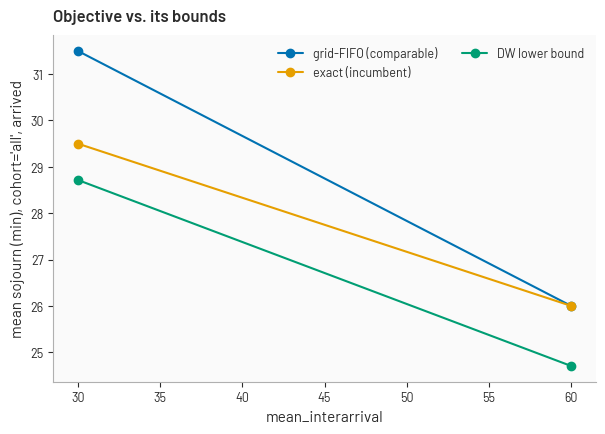

In [12]:
X_AXIS = "mean_interarrival"   # column to put on the x-axis
GROUP_BY = None                # one line per value; set to None to disable
COHORT = "all"                 # "measurement" | "measurement_queued" | "all"
GROUP = "arrived"              # "arrived" (comparable) | "completed"

sources = [
    #(f"sim_{GROUP}_{COHORT}_mean_sojourn", "sim (continuous)"),
    (f"grid_{GROUP}_{COHORT}_mean_sojourn", "grid-FIFO (comparable)"),
    (f"exact_{GROUP}_{COHORT}_mean_sojourn", "exact (incumbent)"),
    ("dw_mean_sojourn_LB", "DW lower bound"),  # DW has no per-cohort LB -- see README
]
sources = [(col, label) for col, label in sources if col in df.columns]
colors = palette(len(sources))
linestyles = ["-", "--", ":", "-."]
groups = sorted(df[GROUP_BY].unique()) if GROUP_BY else [None]

fig, ax = new_figure(figsize=(7, 4.5))
for gi, gval in enumerate(groups):
    sub = df[df[GROUP_BY] == gval].sort_values(X_AXIS) if GROUP_BY else df.sort_values(X_AXIS)
    for (col, label), color in zip(sources, colors):
        line_label = f"{label} ({GROUP_BY}={gval:g})" if GROUP_BY else label
        ax.plot(sub[X_AXIS], sub[col], marker="o", color=color,
                 linestyle=linestyles[gi % len(linestyles)], label=line_label)

ax.set_xlabel(X_AXIS)
ax.set_ylabel(f"mean sojourn (min), cohort='{COHORT}', {GROUP}")
style_axes(ax, title="Objective vs. its bounds")
style_legend(ax, fontsize=7, ncol=2)
plt.show()

## How much of each row is censored?

The censored share is what decides whether a row is trustworthy. A row where
half the vehicles never finished is dominated by the censoring convention,
not by scheduling quality -- that is the regime where the `completed` and
`arrived` groups disagree most, and where a short `max_time` shows up.

`exact_n_completed_at_horizon` counts vehicles that finished *exactly* at the
horizon edge (`D_j == K` yet fully charged). A nonzero count means the
horizon is binding on the optimum, and is also why completion is tested by
energy rather than by departure slot.

In [ ]:
COHORT = "all"
cens = pd.DataFrame({
    "arrived_n": df[f"exact_arrived_{COHORT}_n"],
    "completed_n": df[f"exact_completed_{COHORT}_n"],
    "censored_n": df[f"exact_arrived_{COHORT}_n_censored"],
})
cens["censored_share"] = cens["censored_n"] / cens["arrived_n"]
for col in ("exact_n_completed_at_horizon", "exact_n_at_horizon"):
    if col in df.columns:
        cens[col.replace("exact_", "")] = df[col]
cens.round(3)

## One trial's full detail

`results.csv` is the flattened view; `trials/trial_NNN.json` keeps the same
trial nested (and is where you'd look for anything `flatten_trial` didn't
pull into a column). Note this does NOT include the per-vehicle schedule
table (`ConnectorLaneSolution.per_vehicle` / `DWSolution.per_vehicle`) --
only the aggregate/by-cohort figures `run_exact`/`run_dw` returned. Re-run
`experiments.benchmark_trial.run_exact`/`run_dw` directly on that trial's
config if you need the per-vehicle rows.

In [ ]:
TRIAL_ID = 0  # <-- edit to inspect a different row

trial = json.loads((run_dir / "trials" / f"trial_{TRIAL_ID:03d}.json").read_text())
print("config:", {k: v for k, v in trial["config"].items() if k in
      ("mean_interarrival", "max_time", "delta", "mip_gap", "gap_tolerance",
       "gap_tolerance_target_min", "boundary_mode", "objective_cohorts")})
print()
print("counts:  ", trial["counts"])
print("instance:", trial["instance"])
print()
print("exact:", trial["exact"])
print()
print("dw:   ", trial["dw"])

## Notes / gotchas (see `experiments/README.md` for the full version)

- **`sim` is not the target.** The offline models can only depart on `delta`
  slot boundaries; compare against `grid`, not `sim`.
- **DW has no per-cohort lower bound.** `dw_mean_sojourn_LB` certifies
  whichever `objective_cohorts` that trial was solved over as a whole -- it
  is not a separate bound for `measurement` vs. `all`. If you need a bound
  for one cohort specifically, that cohort must be `objective_cohorts` for
  its own trial.
- **Watch the `n` columns** (`sim_{cohort}_n`, `grid_{cohort}_n`,
  `exact_{cohort}_n`, `dw_n_optimized`) when comparing `sim`/`grid` against
  `exact`/`dw`: the simulation only counts vehicles that *finished* inside
  the run, the offline models count every vehicle they were given. Different
  `n` means different populations -- the mean-sojourn gap is not
  apples-to-apples until `max_time` is long enough that these line up.
- **A sweep over `max_time` (or `warmup_period`) needs `arrival_horizon`
  pinned**, or each value silently redraws the whole EV population instead
  of just changing the window length -- see the README section "Sweeping
  `max_time`: pin the arrival draw".